**Tasks:**
1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel('heart_disease.xlsx', sheet_name=1)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


In [3]:
df.shape

(908, 13)

In [4]:
df.size

11804

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [7]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [10]:
df.dtypes

,0
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,bool
restecg,object
thalch,int64
exang,object
oldpeak,float64


**2. Exploratory Data Analysis (EDA):**   

Perform exploratory data analysis to understand the structure of the dataset.


In [11]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4
907,57,Male,asymptomatic,142,277,True,st-t abnormality,182,FALSE,NaN,flat,normal,4


In [12]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [13]:
df.nunique()

,0
age,49
sex,2
cp,4
trestbps,85
chol,228
fbs,2
restecg,3
thalch,122
exang,4
oldpeak,53


In [14]:
df['num'].value_counts()

,count
num,
0,399
1,265
2,109
3,107
4,28


Check for missing values, outliers, and inconsistencies in the data.

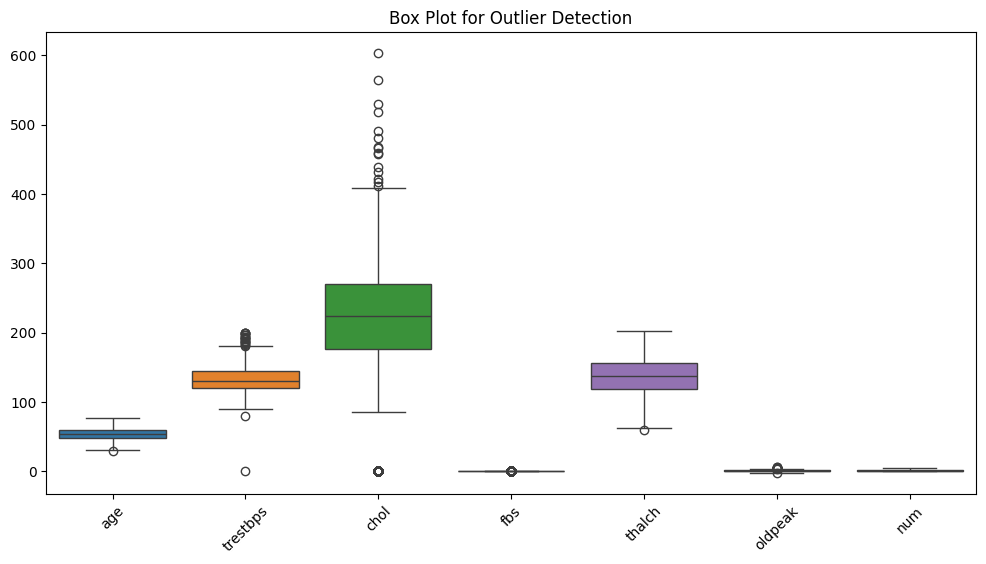

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Box Plot for Outlier Detection")
plt.show()

In [16]:
# Clean 'exang' column by replacing string representations with actual booleans and converting to int (0/1)
df['exang'] = df['exang'].replace({'TURE': True, 'FALSE': False, 'True': True, 'False': False})
df['exang'] = df['exang'].astype(bool).astype(int)

# Convert 'fbs' column to int (0/1) as well, as it's a boolean type and causes issues with quantile subtraction
df['fbs'] = df['fbs'].astype(int)

Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1
outliers = ((df.select_dtypes(include='number') < (Q1 - 1.5 * IQR)) |(df.select_dtypes(include='number') > (Q3 + 1.5 * IQR)))
outliers.sum()

/tmp/ipykernel_1021/3071740571.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'] = df['exang'].replace({'TURE': True, 'FALSE': False, 'True': True, 'False': False})


,0
age,1
trestbps,22
chol,187
fbs,185
thalch,1
exang,0
oldpeak,16
num,0


Visualize the distribution of features, including histograms, box plots, and correlation matrices.

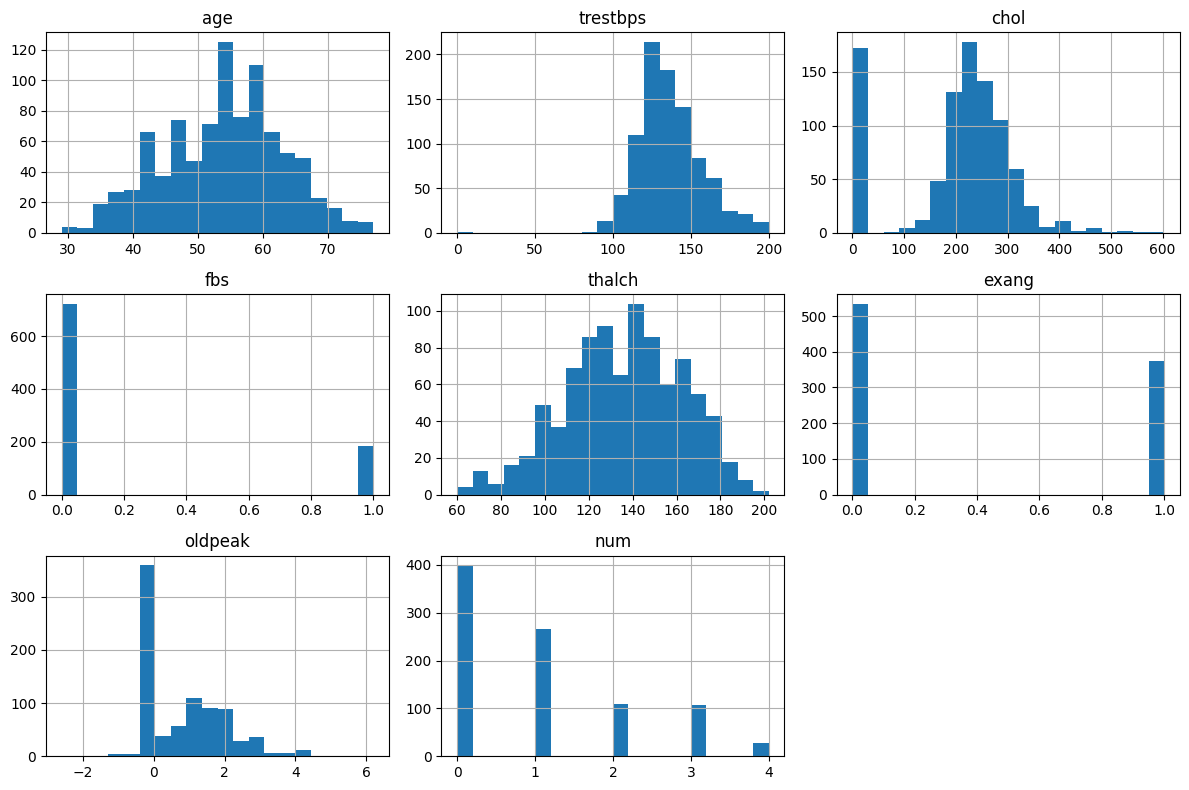

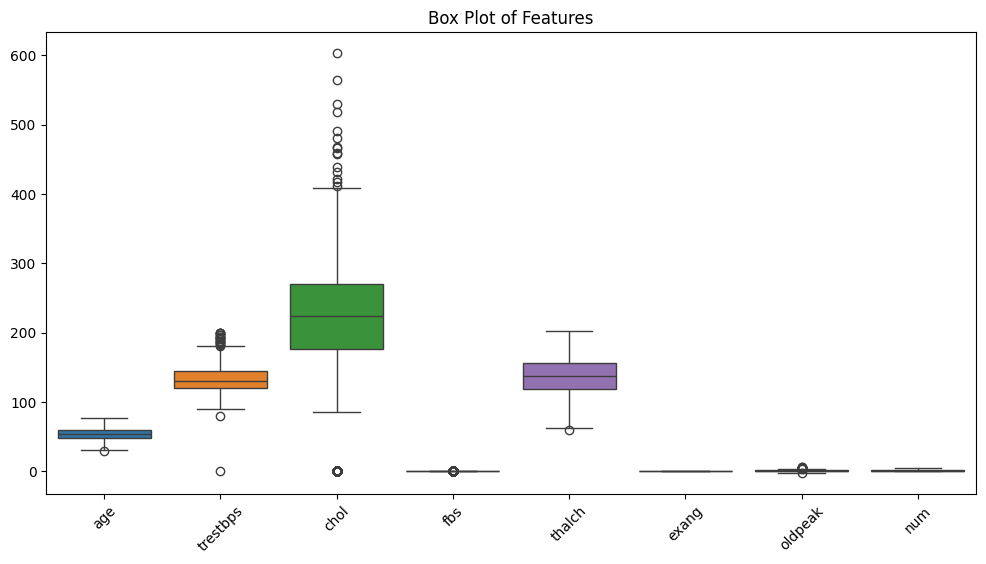

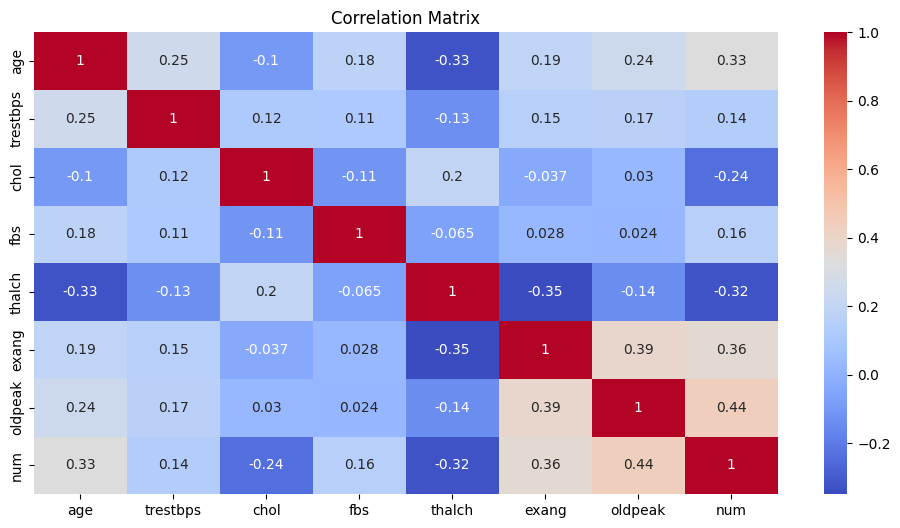

In [21]:
#Histograms
df.hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()
#boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Box Plot of Features")
plt.show()
#Correlation Matrices
plt.figure(figsize=(12,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**3. Feature Engineering:**    
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.


In [22]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [23]:
# Fill missing numerical values with the mean
df.fillna(df.mean(numeric_only=True), inplace=True)

In [24]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [25]:
#Encoding Categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,0,2.3,0,0,0
1,41,1,1,135,203,0,1,132,0,0.0,1,0,0
2,57,1,0,140,192,0,1,148,0,0.4,1,0,0
3,52,1,3,118,186,0,0,190,0,0.0,1,0,0
4,57,1,0,110,201,0,1,126,1,1.5,1,0,0


In [28]:
#scaling numerical Features
'''from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.select_dtypes(include='number'))'''
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df.drop('num', axis=1)
y = df['num']
X_scaled = scaler.fit_transform(X)

In [29]:
#verifed the scaled feature
import pandas as pd
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
0,1.006027,0.514416,2.320276,0.567394,0.281297,1.976894,-1.561352,0.524183,-0.834983,1.334996,-1.672770,-1.553454
1,-1.397560,0.514416,0.232258,0.076967,0.013526,-0.505844,0.013879,-0.147705,-0.834983,-0.844594,-0.224843,-1.553454
2,0.350503,0.514416,-0.811752,0.322181,-0.084656,-0.505844,0.013879,0.449529,-0.834983,-0.465535,-0.224843,-1.553454
3,-0.195767,0.514416,2.320276,-0.756760,-0.138211,-0.505844,-1.561352,2.017268,-0.834983,-0.844594,-0.224843,-1.553454
4,0.350503,0.514416,-0.811752,-1.149102,-0.004325,-0.505844,0.013879,-0.371668,1.197629,0.576878,-0.224843,-1.553454


**4. Decision Tree Classification:**  
Split the dataset into training and testing sets (e.g., using an 80-20 split).


In [31]:
from sklearn.model_selection import train_test_split
# Features and Target
X = df.drop('num', axis=1)
y = df['num']
# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [32]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (726, 12)
Testing Features: (182, 12)
Training Labels: (726,)
Testing Labels: (182,)


Implement a Decision Tree Classification model using a library like scikit-learn.

In [33]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
#Make prediction
y_pred = dt_model.predict(X_test)
print(y_pred)

[1 1 0 2 1 1 1 0 1 1 3 2 0 0 0 2 0 0 0 3 0 1 2 1 0 2 0 0 1 0 0 1 0 1 0 1 0
 0 0 1 4 0 1 0 2 2 1 0 0 1 2 3 0 3 0 0 3 1 1 0 0 0 1 0 0 2 1 1 1 0 0 3 3 1
 0 0 1 0 1 1 0 1 0 0 0 0 0 3 1 2 3 3 0 0 3 2 4 0 1 0 0 0 1 1 0 2 1 1 1 2 0
 0 2 0 0 1 1 1 2 0 0 0 0 0 0 0 0 0 1 1 0 0 2 1 1 0 1 0 2 0 1 0 0 0 2 1 3 0
 1 0 0 0 1 2 0 1 1 0 1 0 1 3 0 0 0 0 3 1 2 3 0 0 0 2 0 4 1 1 4 2 0 0]


Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [34]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [35]:
#predict on test
y_pred = dt_model.predict(X_test)

In [36]:
#import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [39]:
#accuracy, precision, recall, F1-score, ROC-AUC
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1-Score :", f1_score(y_test, y_pred, average='weighted'))
print("ROC-AUC  :", roc_auc_score(y_test, dt_model.predict_proba(X_test), multi_class='ovr', average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred))
#display the classification report
print(classification_report(y_test, y_pred))

Accuracy : 0.5
Precision: 0.50038735211149
Recall   : 0.5
F1-Score : 0.4997924869248399
ROC-AUC  : 0.6408244244320919
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.71      0.72        89
           1       0.30      0.33      0.31        48
           2       0.41      0.41      0.41        22
           3       0.20      0.18      0.19        17
           4       0.00      0.00      0.00         6

    accuracy                           0.50       182
   macro avg       0.33      0.33      0.33       182
weighted avg       0.50      0.50      0.50       182

              precision    recall  f1-score   support

           0       0.72      0.71      0.72        89
           1       0.30      0.33      0.31        48
           2       0.41      0.41      0.41        22
           3       0.20      0.18      0.19        17
           4       0.00      0.00      0.00         6

    accuracy                           0.50

**5. Hyperparameter Tuning:**   
Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.


In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}
#perfom grid search
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, None],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [41]:
#display best hyperparameters
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.530307038261691


In [42]:
#train the best model
best_model = grid_search.best_estimator_

In [43]:
#predict the test
y_pred = best_model.predict(X_test)

In [44]:
#evaluate the tuned model
from sklearn.metrics import accuracy_score, classification_report
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.5714285714285714
              precision    recall  f1-score   support

           0       0.71      0.85      0.78        89
           1       0.43      0.50      0.46        48
           2       0.00      0.00      0.00        22
           3       0.21      0.24      0.22        17
           4       0.00      0.00      0.00         6

    accuracy                           0.57       182
   macro avg       0.27      0.32      0.29       182
weighted avg       0.48      0.57      0.52       182



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**6. Model Evaluation and Analysis:**  

Analyse the performance of the Decision Tree model using the evaluation metrics obtained.


**Model Evaluation and Analysis**
**Accuracy**: Measures the overall percentage of correctly classified instances. A higher accuracy indicates better overall model performance.   
**Precision:** Measures how many of the predicted positive cases are actually positive. High precision means the model produces fewer false positives.   
**Recall:** Measures how many actual positive cases are correctly identified by the model. High recall indicates fewer false negatives.    
**F1-Score:** The harmonic mean of precision and recall. It provides a balanced evaluation when both false positives and false negatives are important.   
**ROC-AUC:** Measures the model's ability to distinguish between the two classes. A value closer to 1.0 indicates excellent classification performance, while 0.5 indicates random guessing.   
**Overall Analysis**
The Decision Tree classifier successfully learned patterns from the training data and classified the testing data into No Response (0) and Positive Response (1).  
The evaluation metrics indicate how well the model generalizes to unseen data.  
If the model achieves high accuracy, precision, recall, F1-score, and ROC-AUC, it can be considered effective for predicting drug responses.   
If performance is lower than expected, hyperparameter tuning (such as adjusting max_depth, min_samples_split, and criterion) or additional feature engineering may improve the model.  
Comparing the Decision Tree with other classifiers (such as SVM or Random Forest) can help determine the most suitable model for this dataset.

Visualize the decision tree structure to understand the rules learned by the model and identify important features

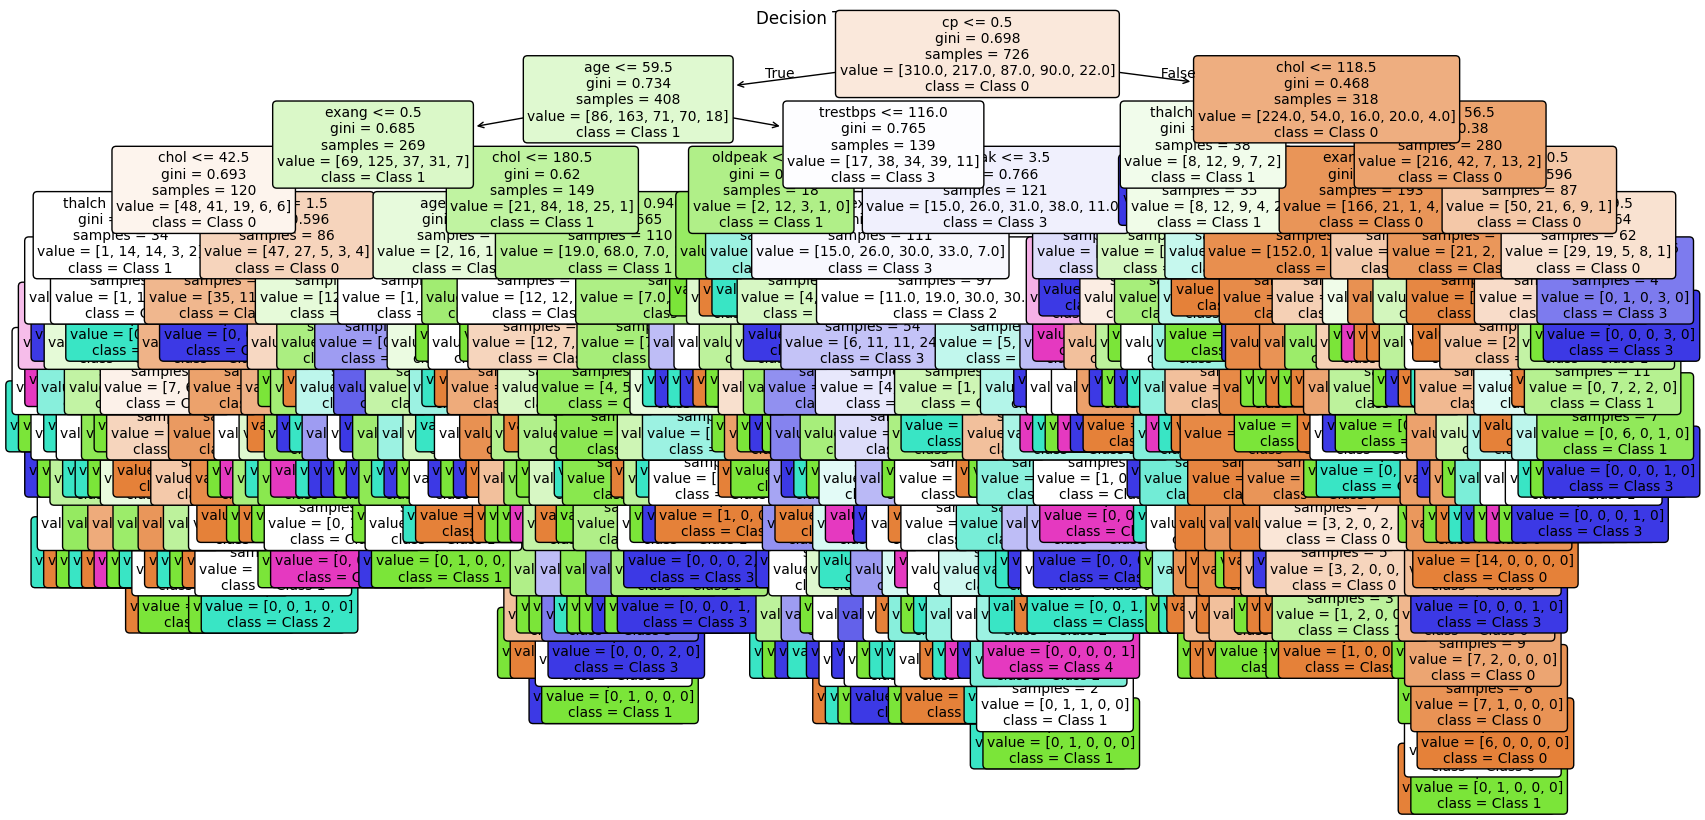

In [47]:
#visualize the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt_model,feature_names=X.columns,class_names=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'],filled=True,rounded=True,fontsize=10)
plt.title("Decision Tree Structure")
plt.show()

In [48]:
#feature importance
feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': dt_model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

     Feature  Importance
7     thalch    0.175914
4       chol    0.153328
0        age    0.152147
3   trestbps    0.132672
2         cp    0.121434
9    oldpeak    0.092811
8      exang    0.040441
11      thal    0.031076
6    restecg    0.027637
5        fbs    0.027404
1        sex    0.023817
10     slope    0.021320


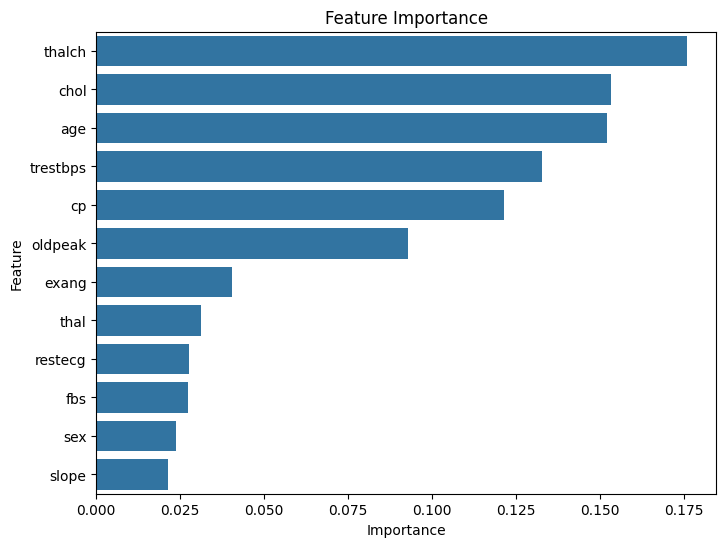

In [49]:
#visualize feature importance
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance")
plt.show()

**Interview Questions:**
1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?


The common hyperparameters of a Decision Tree and their effects are:  
**max_depth**   
Controls the maximum depth of the tree.    
A smaller value helps prevent overfitting.    
A larger value may improve training accuracy but can lead to overfitting.   
**min_samples_split**    
Specifies the minimum number of samples required to split an internal node.   
Higher values create simpler trees and reduce overfitting.    
Lower values allow more splits, increasing model complexity.
**min_samples_leaf**    
Defines the minimum number of samples required in each leaf node.
Larger values produce smoother and more generalized models.    
Smaller values may result in overfitting.   
**criterion**     
Determines the measure used to evaluate the quality of a split.
gini: Uses Gini Impurity; generally faster.
entropy: Uses Information Gain; may produce slightly better splits but is computationally slower.  
**max_features**     
Specifies the maximum number of features considered for each split.
Limiting the number of features can reduce overfitting and improve generalization.    
**splitter**
Controls how the best split is selected.   
best: Chooses the optimal split.    
random: Chooses a random split, which can reduce variance.

2. What is the difference between the Label encoding and One-hot encoding?

**Label Encoding**    
Converts each category into a   unique integer.    
Creates only one new column.      
Best suited for ordinal categorical data (where categories have a natural order).             
May introduce an unintended numerical relationship between categories.      
Uses less memory.     
**One-Hot Encoding**        
Converts each category into a separate binary (0 or 1) column.    
Creates multiple new columns (one for each category).     
Best suited for nominal categorical data (where categories have no natural order).      
Does not create any numerical relationship between categories.    
Uses more memory, especially with many categories.